In [ ]:
import numpy as np
import pandas as pd
from google.colab import auth, drive
from google.cloud import bigquery
import os
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# Mount
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# big query auth
auth.authenticate_user()
client = bigquery.Client(project='ace-apex-508114-n9')

# Helper Functions

In [ ]:
# BigQuery: baseline CXR images per cohort-level stay, with label and demographics
def fetch_bigquery_manifest(bq_client):
    """
    One row per (cohort level, stay, CXR JPG image) in the baseline window,
    for stays with all 5 modalities. Each level uses its own index stay.
    """
    print("Fetching cohort data and baseline CXR images from BigQuery...")
    query = """
        SELECT
          a.level_id, a.stay_id, a.subject_id, a.died_1y, a.age, a.sex,
          CASE
            WHEN adm.race LIKE 'WHITE%' THEN 'White'
            WHEN adm.race LIKE 'BLACK%' THEN 'Black'
            WHEN adm.race LIKE 'HISPANIC%' OR adm.race LIKE 'SOUTH AMERICAN%' THEN 'Hispanic/Latino'
            WHEN adm.race LIKE 'ASIAN%' THEN 'Asian'
            WHEN adm.race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') OR adm.race IS NULL THEN 'Unknown'
            ELSE 'Other'
          END AS race_group,
          CASE
            WHEN a.age < 65 THEN '18-64'
            WHEN a.age < 75 THEN '65-74'
            WHEN a.age < 85 THEN '75-84'
            ELSE '>=85'
          END AS age_group,
          m.record_id, m.study_id, m.view_position, m.hours_from_icu_admit
        FROM `ace-apex-508114-n9.phase0.x_file_manifest` m
        INNER JOIN `ace-apex-508114-n9.phase0.analysis_dataset` a
            ON a.stay_id = m.stay_id
        LEFT JOIN `physionet-data.mimiciv_3_1_hosp.admissions` adm
            ON adm.hadm_id = a.hadm_id
        WHERE m.file_role = 'cxr_image_jpg'
          AND m.phase = 'baseline'
          AND a.has_all5
          AND a.level_id IN ('L1', 'L2', 'L3')
    """
    manifest_df = bq_client.query(query).to_dataframe()
    manifest_df['record_id_str'] = manifest_df['record_id'].astype(str).str.strip()
    print(f"Loaded {manifest_df.shape[0]:,} image rows "
          f"({manifest_df.groupby('level_id').stay_id.nunique().to_dict()} stays per level)")
    return manifest_df

# CXR embedding loader
def load_cxr_embeddings(file_path):
    """
    Loads the given NPZ embeddings file and returns a DataFrame with one row per image,
    keyed by dicom_id (filename without folder or extension).
    """
    print(f"Loading embeddings from: {file_path}")
    cxr_data_loaded = np.load(file_path, allow_pickle=True)
    filenames_array = cxr_data_loaded['filenames']
    embeddings_raw = cxr_data_loaded['embeddings']

    if embeddings_raw.dtype == object or len(embeddings_raw.shape) == 1:
        embeddings_matrix = np.vstack(embeddings_raw)
    else:
        embeddings_matrix = embeddings_raw

    col_names = [f've_{i}' for i in range(embeddings_matrix.shape[1])]
    emb_df = pd.DataFrame(embeddings_matrix, columns=col_names)
    emb_df['filename'] = [str(f) for f in filenames_array]
    # "cxr/30001234/<dicom_id>.jpg" or "<dicom_id>.jpg" -> "<dicom_id>"
    emb_df['record_id_str'] = emb_df['filename'].map(
        lambda f: os.path.splitext(os.path.basename(f.strip()))[0])

    n_dupes = emb_df['record_id_str'].duplicated().sum()
    if n_dupes:
        print(f"Warning: {n_dupes:,} duplicate dicom_ids in embeddings; keeping the first")
        emb_df = emb_df.drop_duplicates('record_id_str')

    print(f"Successfully loaded {emb_df.shape[0]:,} embeddings with {embeddings_matrix.shape[1]} dims")
    return emb_df, col_names

# Load data

In [ ]:
# Fetch cohort manifest (images + labels + demographics)
cxr_manifest_df = fetch_bigquery_manifest(client)

# Load image embeddings (Comment/uncomment the desired model)
# NOTE: Building out more, for now it supports chexfound and medsiglip
#cxr_df, embedding_cols = load_cxr_embeddings('/content/drive/MyDrive/MIMIC_embedding/cxr_medsiglip/medsiglip_all.npz')
cxr_df, embedding_cols = load_cxr_embeddings('/content/drive/MyDrive/MIMIC_embedding/cxr_chexfound_concat/chexfound_concat_all.npz')

# Join on dicom_id
raw_merged_df = pd.merge(cxr_manifest_df, cxr_df, on='record_id_str', how='inner')
print(f"Matched {raw_merged_df.shape[0]:,} of {cxr_manifest_df.shape[0]:,} image rows to an embedding")

# One image per (level, stay): frontal (AP/PA) first, then the latest in the baseline window
raw_merged_df['frontal'] = raw_merged_df['view_position'].isin(['AP', 'PA'])
final_data_df = (raw_merged_df
                 .sort_values(['level_id', 'stay_id', 'frontal', 'hours_from_icu_admit'],
                              ascending=[True, True, False, False])
                 .drop_duplicates(subset=['level_id', 'stay_id'])
                 .copy())
final_data_df['outcome'] = final_data_df['died_1y'].map({True: 'Died', False: 'Survived'})

# Stays lost because their images have no embedding (e.g. L1/L2 stays not yet downloaded)
coverage = pd.DataFrame({
    'stays_all5_with_cxr': cxr_manifest_df.groupby('level_id').stay_id.nunique(),
    'stays_with_embedding': final_data_df.groupby('level_id').stay_id.nunique(),
})
coverage['missing'] = coverage.iloc[:, 0] - coverage.iloc[:, 1]
print(coverage)
print(f"final_data_df: {final_data_df.shape[0]:,} rows = one per (level, stay); "
      f"filter by level_id before modelling")

Fetching cohort data and baseline CXR images from BigQuery...
Loaded 10,288 image rows ({'L1': 997, 'L2': 1489, 'L3': 2323} stays per level)
Loading embeddings from: /content/drive/MyDrive/MIMIC_embedding/cxr_chexfound_concat/chexfound_concat_all.npz
Successfully loaded 243,334 embeddings with 2048 dims
Matched 9,191 of 10,288 image rows to an embedding
          stays_all5_with_cxr  stays_with_embedding  missing
level_id                                                    
L1                        997                   997        0
L2                       1489                  1486        3
L3                       2323                  2321        2
final_data_df: 4,804 rows = one per (level, stay); filter by level_id before modelling


# Exploring Demographics

=== Patient Counts per Cohort ===
Cohort L1: 997 patients, 355 died within 1y (35.6%)
Cohort L2: 1,486 patients, 489 died within 1y (32.9%)
Cohort L3: 2,321 patients, 584 died within 1y (25.2%)


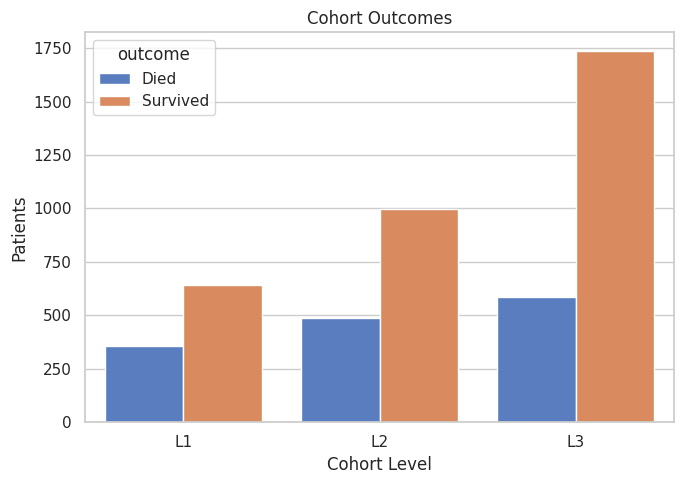

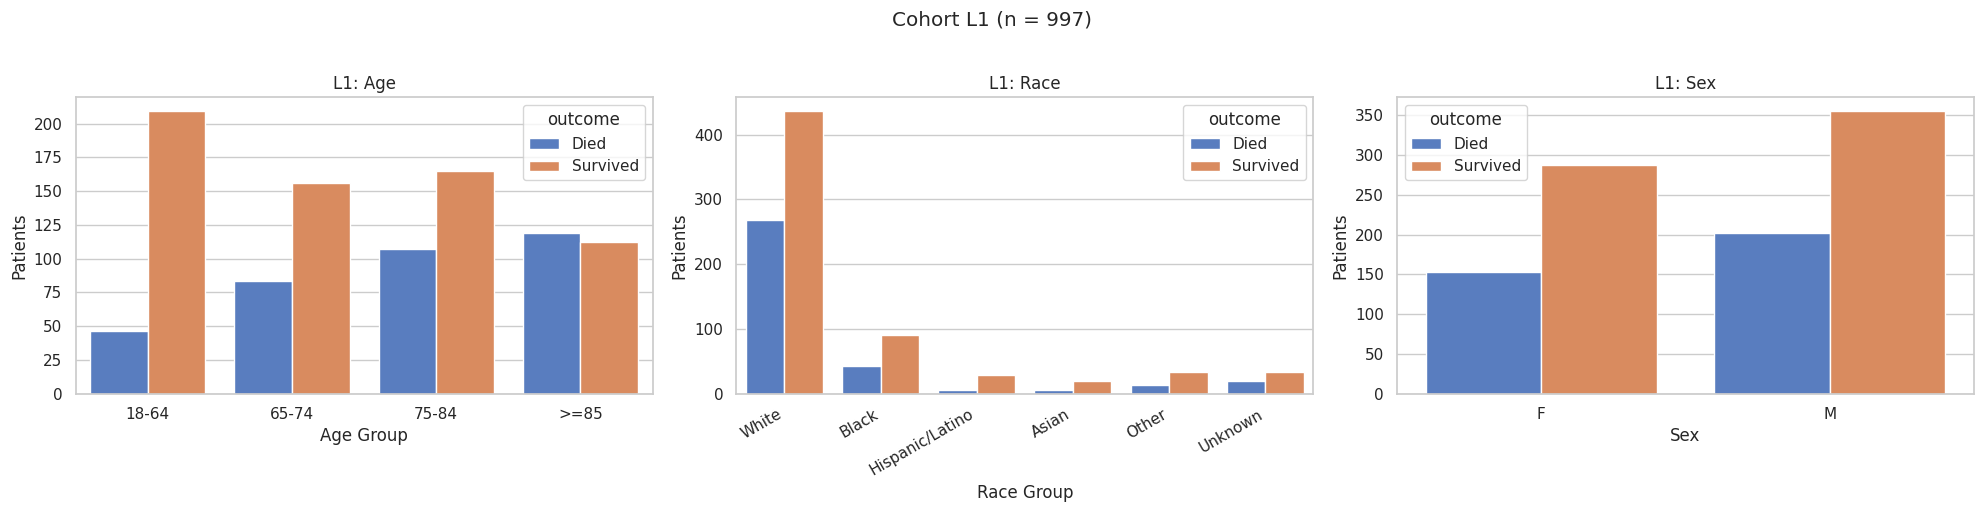

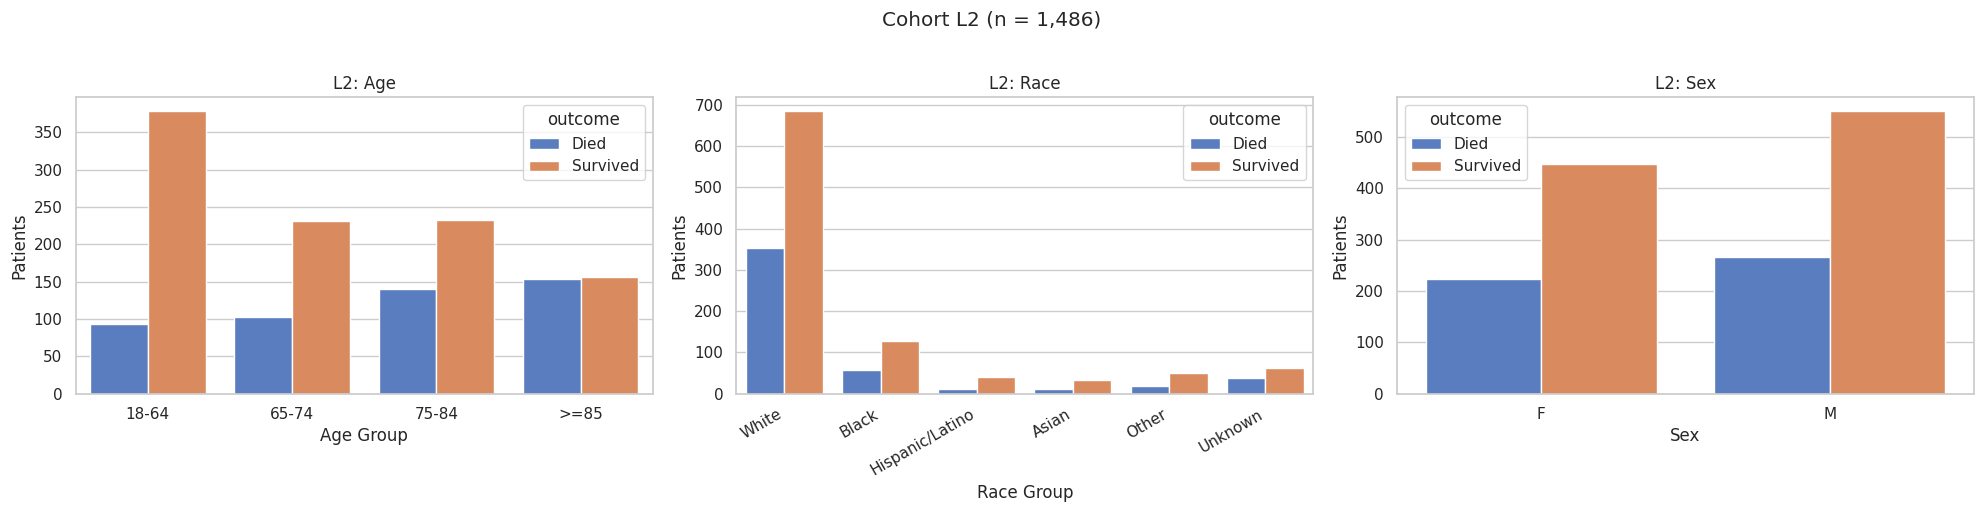

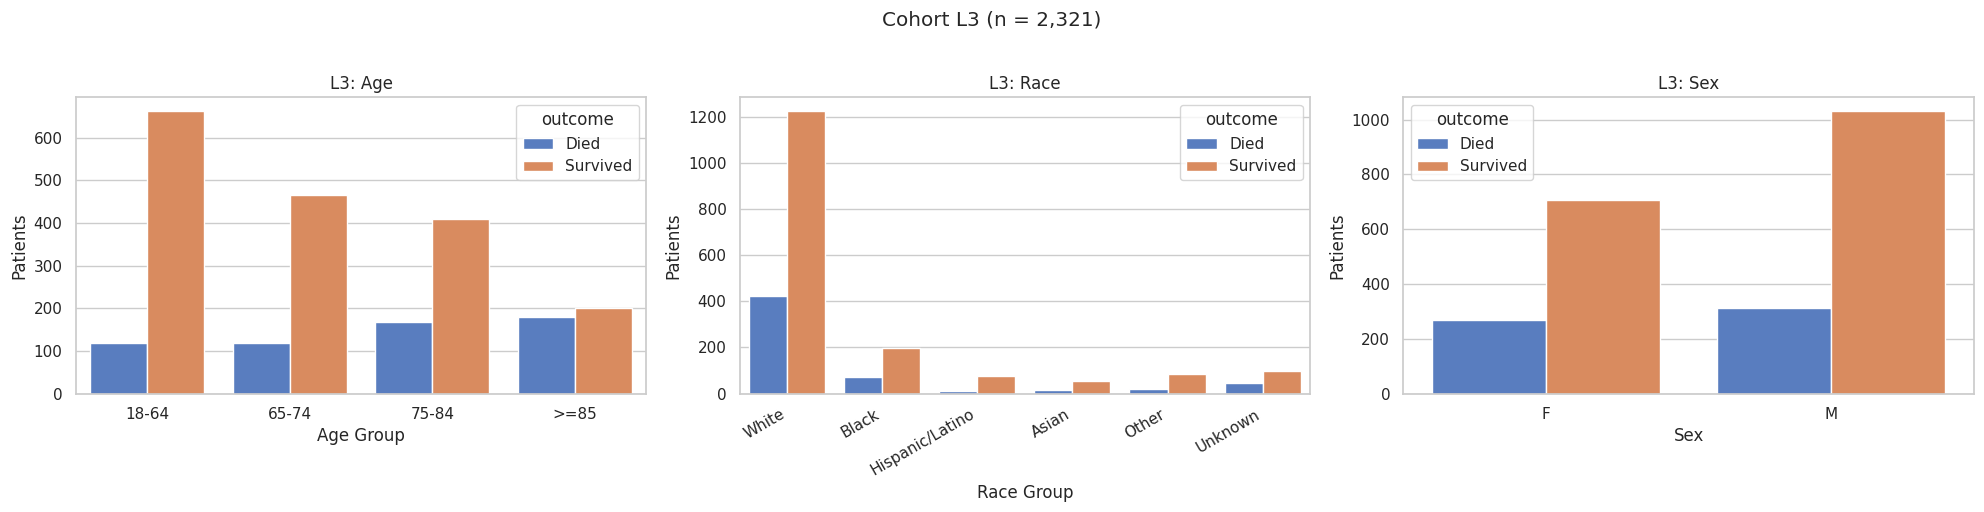

In [ ]:
dem_patient_df = final_data_df

print("=== Patient Counts per Cohort ===")
for lvl in ['L1', 'L2', 'L3']:
    d = dem_patient_df[dem_patient_df['level_id'] == lvl]
    print(f"Cohort {lvl}: {d['subject_id'].nunique():,} patients, "
          f"{d['died_1y'].sum():,} died within 1y ({100 * d['died_1y'].mean():.1f}%)")

sns.set_theme(style="whitegrid")
race_order = ['White', 'Black', 'Hispanic/Latino', 'Asian', 'Other', 'Unknown']
age_order = ['18-64', '65-74', '75-84', '>=85']

# Panel 1: outcomes per cohort level (each patient counted once within its level)
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=dem_patient_df, x='level_id', hue='outcome', ax=ax,
              palette='muted', order=['L1', 'L2', 'L3'])
ax.set(title='Cohort Outcomes', xlabel='Cohort Level', ylabel='Patients')
plt.tight_layout()
plt.show()

# Panels 2-4: demographics, one row of plots per cohort level
for lvl in ['L1', 'L2', 'L3']:
    d = dem_patient_df[dem_patient_df['level_id'] == lvl]
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.countplot(data=d, x='age_group', hue='outcome', ax=axes[0], palette='muted', order=age_order)
    axes[0].set(title=f'{lvl}: Age', xlabel='Age Group', ylabel='Patients')

    sns.countplot(data=d, x='race_group', hue='outcome', ax=axes[1], palette='muted', order=race_order)
    axes[1].set(title=f'{lvl}: Race', xlabel='Race Group', ylabel='Patients')
    axes[1].set_xticks(range(len(race_order)))
    axes[1].set_xticklabels(race_order, rotation=30, ha='right')

    sns.countplot(data=d, x='sex', hue='outcome', ax=axes[2], palette='muted', order=['F', 'M'])
    axes[2].set(title=f'{lvl}: Sex', xlabel='Sex', ylabel='Patients')

    fig.suptitle(f'Cohort {lvl} (n = {d.subject_id.nunique():,})', y=1.02)
    plt.tight_layout()
    plt.show()


# Embedding Visualization

In [ ]:
def plot_umap_cohorts_faceted(final_df, embedding_cols, levels=['L1', 'L2', 'L3'], random_state=88):
    """
    2D UMAP of CXR embeddings per cohort level (one image per patient),
    coloured by 1-year outcome, sex, age group and race group.
    Expects final_data_df: one row per (level_id, stay_id).
    """
    orders = {
        'outcome':    ['Survived', 'Died'],
        'sex':        ['F', 'M'],
        'age_group':  ['18-64', '65-74', '75-84', '>=85'],
        'race_group': ['White', 'Black', 'Hispanic/Latino', 'Asian', 'Other', 'Unknown'],
    }

    outcome_palette = {'Survived': '#1E88E5', 'Died': '#D81B60'}
    color_vars = [
        ('outcome',    '1-Year Outcome', outcome_palette),
        ('sex',        'Sex',            'Set1'),
        ('age_group',  'Age Group',      'viridis'),
        ('race_group', 'Race Group',     'tab10'),
    ]

    for level in levels:
        cohort_subset = final_df[final_df['level_id'] == level].dropna(subset=embedding_cols).copy()
        if cohort_subset.empty:
            print(f"Cohort {level} has no matched data. Skipping.")
            continue
        assert cohort_subset['subject_id'].is_unique, \
            f"{level}: more than one row per patient; pass final_data_df, not raw_merged_df"

        print(f"\nRunning UMAP for Cohort {level} (N={len(cohort_subset):,} patients)...")
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=random_state)
        xy = reducer.fit_transform(cohort_subset[embedding_cols].values)
        cohort_subset['umap_x'], cohort_subset['umap_y'] = xy[:, 0], xy[:, 1]

        fig, axes = plt.subplots(1, 4, figsize=(28, 6.5))
        for ax, (col_var, title, palette) in zip(axes, color_vars):
            if col_var not in cohort_subset.columns:
                ax.set_title(f"{title} (missing column)")
                continue
            sns.scatterplot(data=cohort_subset, x='umap_x', y='umap_y', hue=col_var,
                            hue_order=[v for v in orders[col_var] if v in set(cohort_subset[col_var])],
                            ax=ax, alpha=0.7, s=12, palette=palette)
            ax.set(title=f"{level} - {title}", xlabel="UMAP Dim 1", ylabel="UMAP Dim 2")
            ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left')
            ax.grid(True, alpha=0.3)

        plt.suptitle(f"Cohort {level} CXR embeddings (N={len(cohort_subset):,} patients)", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()


Running UMAP for Cohort L1 (N=997 patients)...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


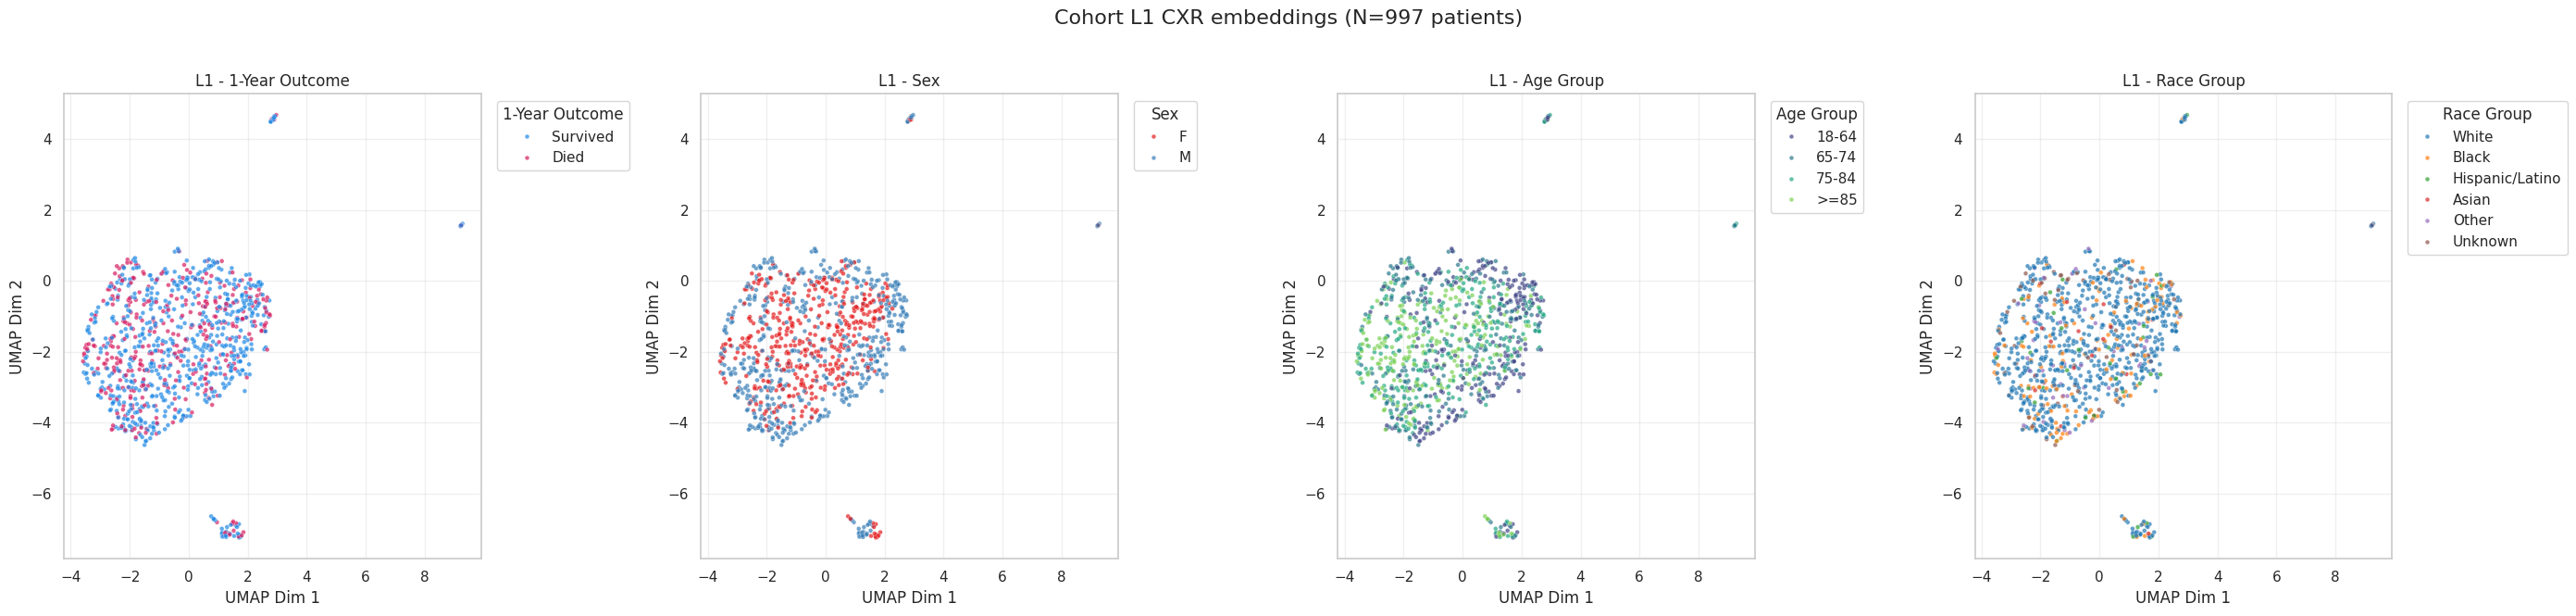


Running UMAP for Cohort L2 (N=1,486 patients)...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


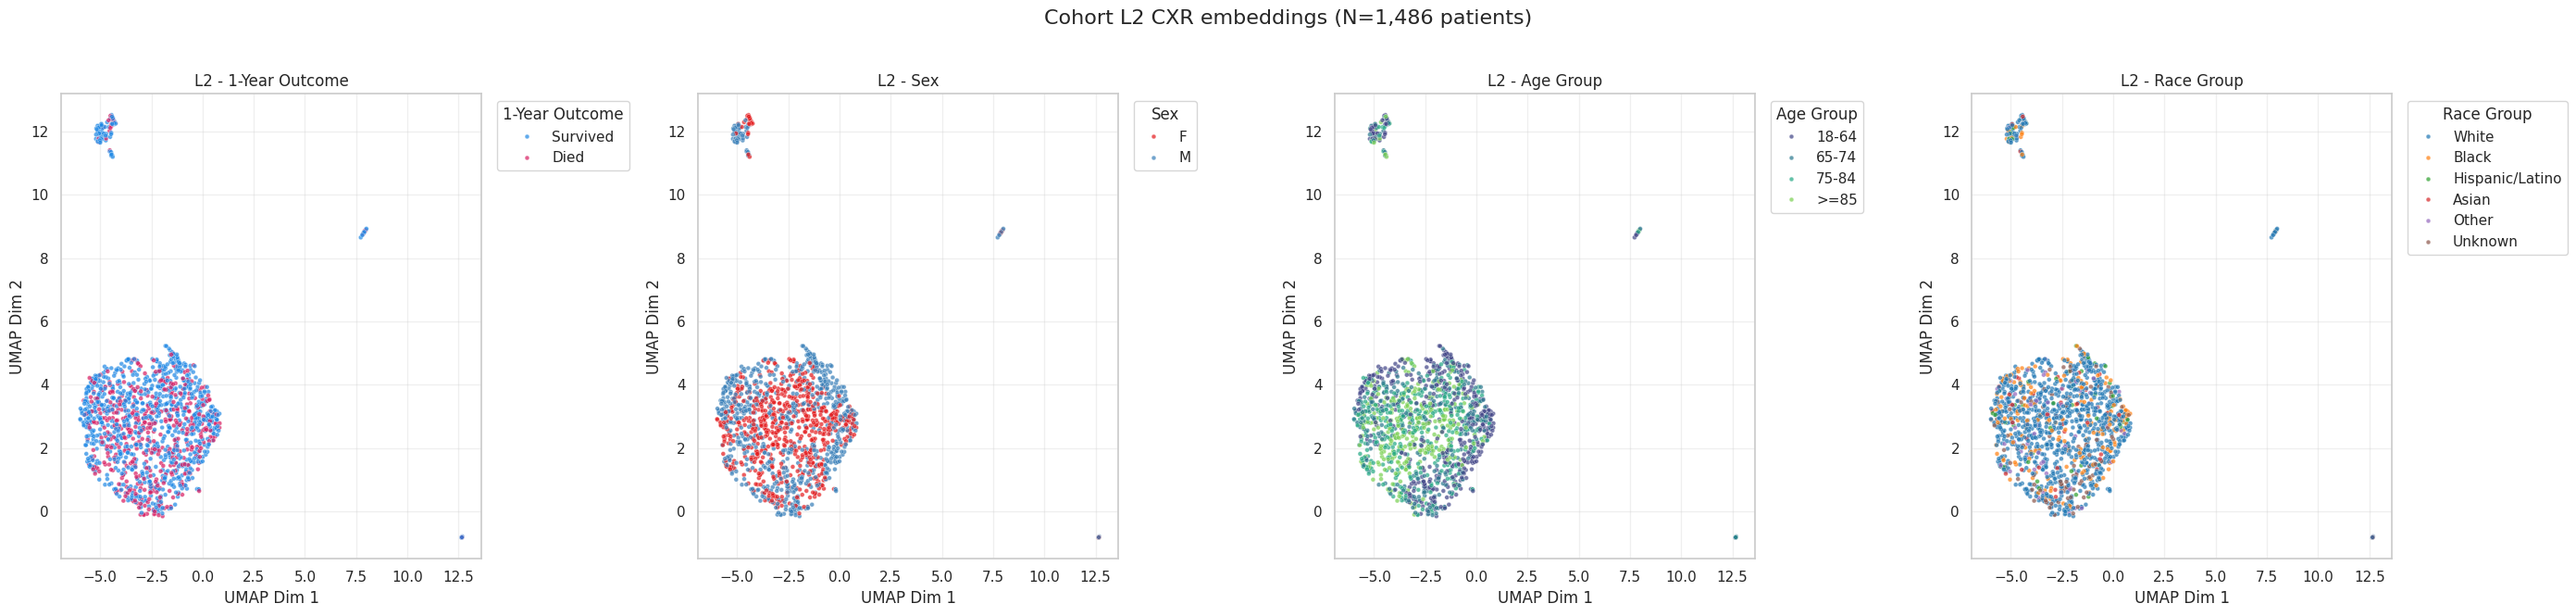


Running UMAP for Cohort L3 (N=2,321 patients)...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


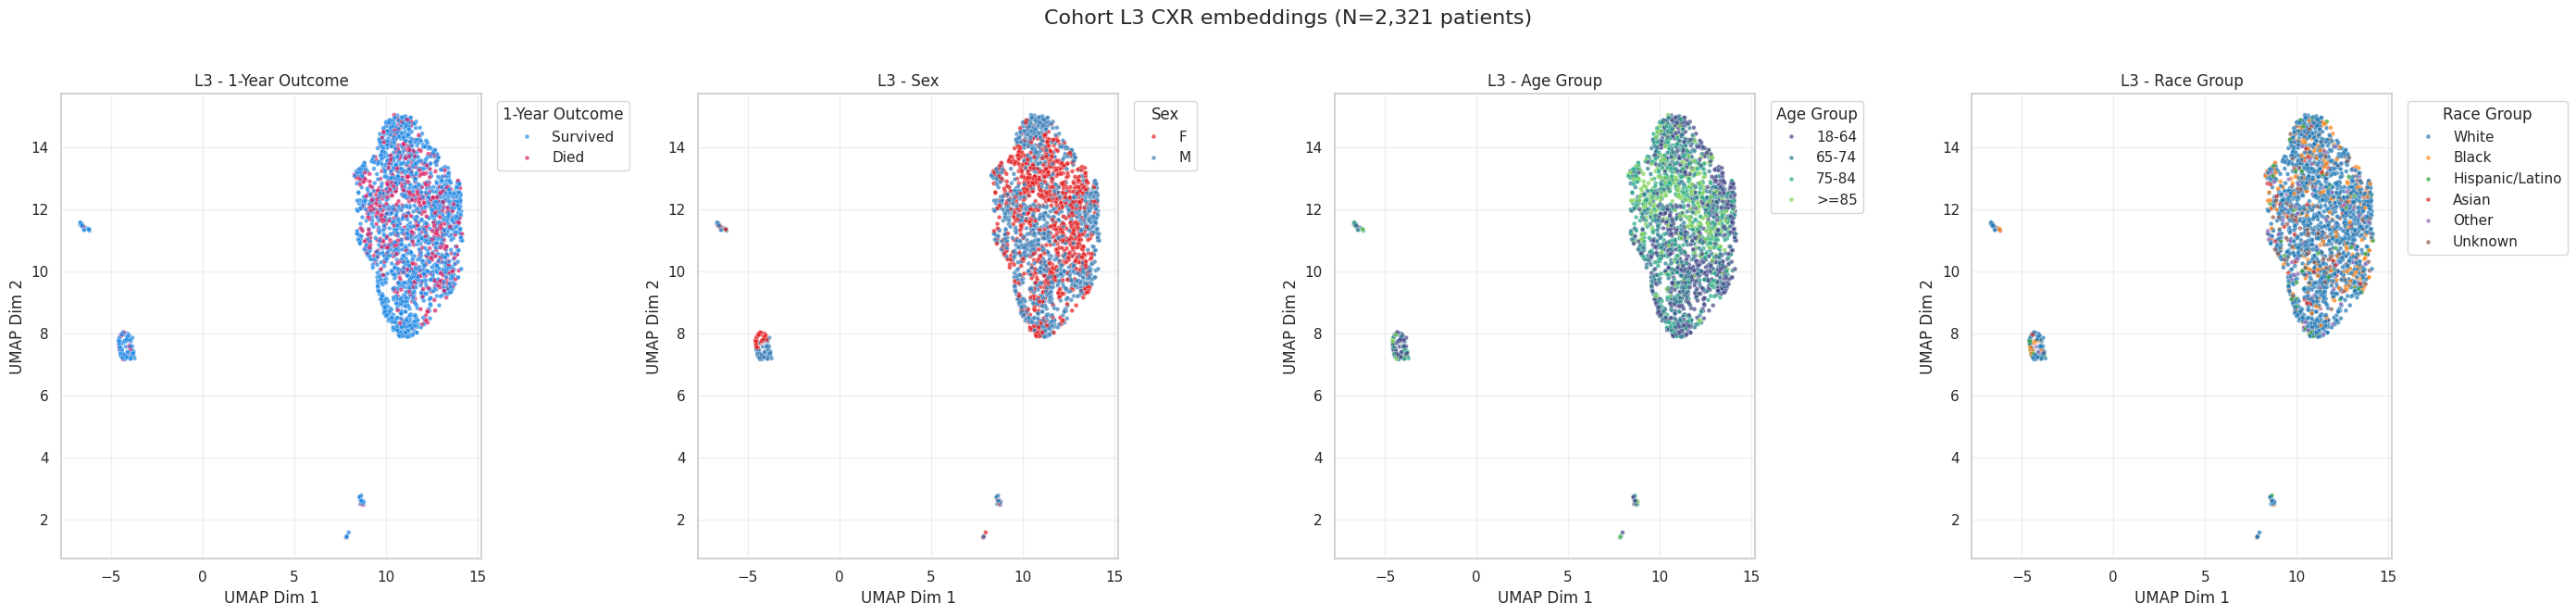

In [ ]:
plot_umap_cohorts_faceted(final_data_df, embedding_cols)

# Unimodal probe

In [ ]:
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score,
                             f1_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset splitting
def split_cohort_data(df, embedding_cols, target_col='died_1y', test_size=0.1, val_size=0.1, random_state=88):
    """
    One cohort level in, stratified 70/15/15 patient-level split out.
    Returns standardized image embeddings (X) and demographics (D: age, male) for each split.
    Scalers are fit on the training split only.
    """
    model_df = df.dropna(subset=embedding_cols + ['age', 'sex']).copy()
    assert model_df['subject_id'].is_unique, "filter to one level_id first (one row per patient)"

    X = model_df[embedding_cols].values
    D = np.column_stack([model_df['age'].astype(float).values,
                         (model_df['sex'] == 'M').astype(int).values])
    y = model_df[target_col].astype(int).values

    idx = np.arange(len(y))
    idx_tv, idx_te = train_test_split(idx, test_size=test_size, stratify=y, random_state=random_state)
    idx_tr, idx_va = train_test_split(idx_tv, test_size=val_size / (1 - test_size),
                                      stratify=y[idx_tv], random_state=random_state)

    xs = StandardScaler().fit(X[idx_tr])
    ds = StandardScaler().fit(D[idx_tr])
    Xs, Ds = xs.transform(X), ds.transform(D)

    print(f"N={len(y):,} ({y.sum():,} died, {100 * y.mean():.1f}%) | "
          f"train {len(idx_tr):,} / val {len(idx_va):,} / test {len(idx_te):,} "
          f"({y[idx_te].sum()} deaths in test)")
    return (Xs[idx_tr], Xs[idx_va], Xs[idx_te],
            Ds[idx_tr], Ds[idx_va], Ds[idx_te],
            y[idx_tr], y[idx_va], y[idx_te])


# 2. Logistic regression, L2 strength C tuned on validation AUROC
def train_logistic_classifier(X_train, y_train, X_val=None, y_val=None, random_state=88):
    c_candidates = [0.001, 0.01, 0.1, 0.5, 1.0, 2.5, 10]

    def fit(c):
        return LogisticRegression(penalty='l2', solver='lbfgs', max_iter=2000, C=c,
                                  class_weight='balanced', random_state=random_state).fit(X_train, y_train)

    if X_val is None or y_val is None:
        return fit(1.0)

    best_clf, best_c, best_auc = None, None, -1.0
    for c in c_candidates:
        clf = fit(c)
        auc = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
        if auc > best_auc:
            best_clf, best_c, best_auc = clf, c, auc
    print(f"  LR: best C = {best_c} (val AUROC {best_auc:.4f})")
    return best_clf


# 3. Simple neural network
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


def train_single_nn(X_train, y_train, X_val, y_val, hidden_dim, epochs=50, batch_size=64, lr=0.001, random_state=88):
    torch.manual_seed(random_state)
    model = SimpleNN(input_dim=X_train.shape[1], hidden_dim=hidden_dim, dropout_rate=0.3)

    loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train).unsqueeze(1)),
                        batch_size=batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(random_state))
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    X_val_t, y_val_t = torch.FloatTensor(X_val), torch.FloatTensor(y_val).unsqueeze(1)

    best_val_loss, best_weights = float('inf'), None
    for _ in range(epochs):
        model.train()
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())   # deep copy: keeps this epoch's weights

    model.load_state_dict(best_weights)
    return model, best_val_loss


def train_nn_classifier(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.001, random_state=88):
    input_dim = X_train.shape[1]
    best_model, best_loss, best_dim = None, float('inf'), None
    for hidden_dim in [max(input_dim // 2, 1), max(input_dim // 4, 1), max(input_dim // 8, 1), max(input_dim // 16, 1)]:
        model, val_loss = train_single_nn(X_train, y_train, X_val, y_val, hidden_dim,
                                          epochs, batch_size, lr, random_state)
        if val_loss < best_loss:
            best_model, best_loss, best_dim = model, val_loss, hidden_dim
    print(f"  NN: best hidden size = {best_dim} (val loss {best_loss:.4f})")
    return best_model


def nn_predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.FloatTensor(X)).numpy().ravel()


# 4. Threshold and confidence intervals
def youden_threshold(y_val, p_val):
    """Threshold maximizing sensitivity + specificity - 1 on the validation set."""
    fpr, tpr, thr = roc_curve(y_val, p_val)
    return float(thr[np.argmax(tpr - fpr)])


def bootstrap_ci(y_true, y_prob, metric=roc_auc_score, n=1000, seed=88):
    rng = np.random.default_rng(seed)
    stats = []
    for _ in range(n):
        i = rng.integers(0, len(y_true), len(y_true))
        if y_true[i].min() == y_true[i].max():
            continue
        stats.append(metric(y_true[i], y_prob[i]))
    return np.percentile(stats, [2.5, 97.5])


# 5. Evaluation and plots
def evaluate_and_plot(y_true, y_pred_prob, title_suffix, threshold=0.5, plot=True):
    """
    Threshold-free metrics (AUROC with 95% bootstrap CI, AUPRC) plus metrics at `threshold`
    (choose it on the validation set, not the test set).
    """
    y_pred = (y_pred_prob >= threshold).astype(int)
    auroc = roc_auc_score(y_true, y_pred_prob)
    lo, hi = bootstrap_ci(y_true, y_pred_prob)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'AUROC': round(auroc, 4),
        'AUROC 95% CI': f"{lo:.3f}-{hi:.3f}",
        'AUPRC': round(average_precision_score(y_true, y_pred_prob), 4),
        'F1': round(f1_score(y_true, y_pred, zero_division=0), 4),
        'PPV (Precision)': round(tp / (tp + fp), 4) if (tp + fp) else 0.0,
        'NPV': round(tn / (tn + fn), 4) if (tn + fn) else 0.0,
        'Sensitivity (Recall)': round(tp / (tp + fn), 4) if (tp + fn) else 0.0,
        'Specificity': round(tn / (tn + fp), 4) if (tn + fp) else 0.0,
        'Threshold': round(threshold, 4),
    }

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
        axes[0].plot(fpr, tpr, color='darkorange', lw=2,
                     label=f'AUC = {auroc:.3f} (95% CI {lo:.3f}-{hi:.3f})')
        axes[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
        axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title=f'ROC Curve - {title_suffix}')
        axes[0].legend(loc='lower right')
        axes[0].grid(True, alpha=0.3)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                    xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'])
        axes[1].set(xlabel='Predicted Label', ylabel='True Label',
                    title=f'Confusion Matrix - {title_suffix} (threshold {threshold:.3f})')
        plt.tight_layout()
        plt.show()

    return metrics

### Cohort-by-Cohort Evaluation and Side-by-Side Comparison


PROCESSING COHORT: L1
N=997 (355 died, 35.6%) | train 797 / val 100 / test 100 (36 deaths in test)
  LR: best C = 0.01 (val AUROC 0.7365)


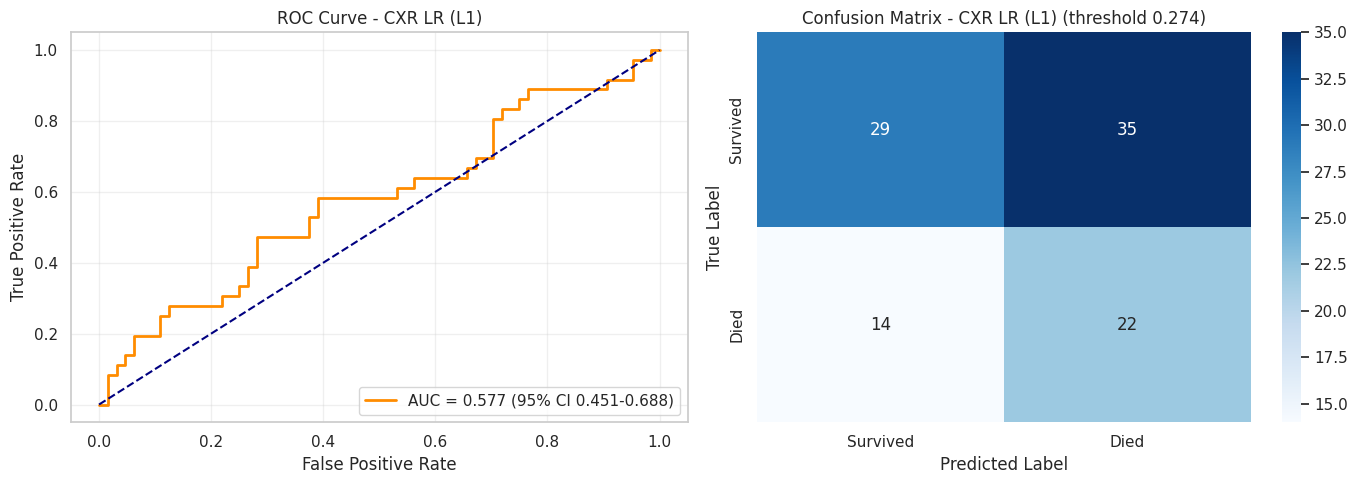

  NN: best hidden size = 128 (val loss 0.5601)


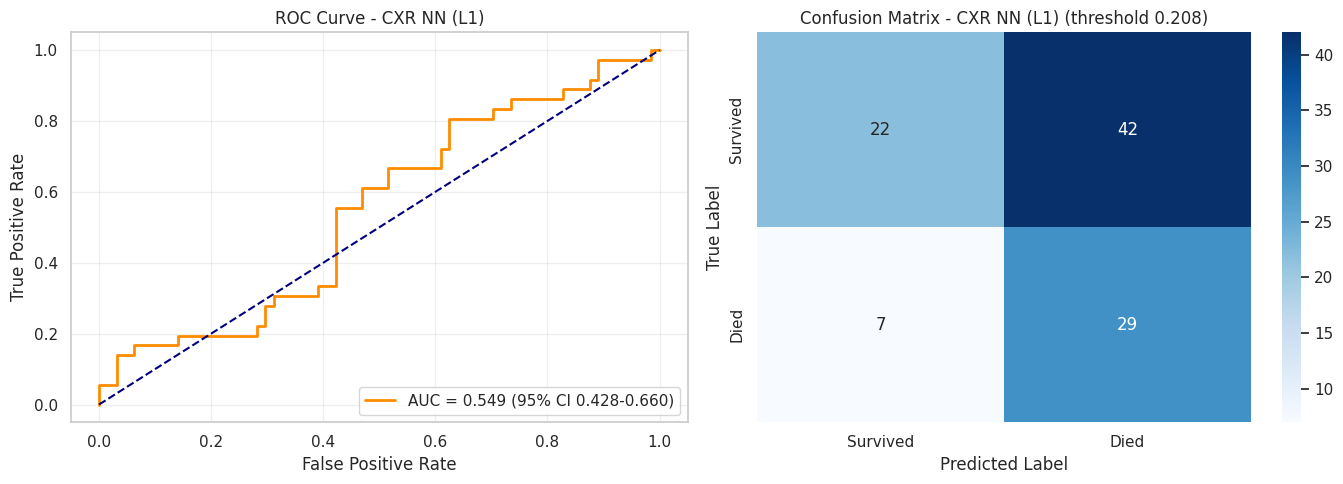

  LR: best C = 0.5 (val AUROC 0.6875)


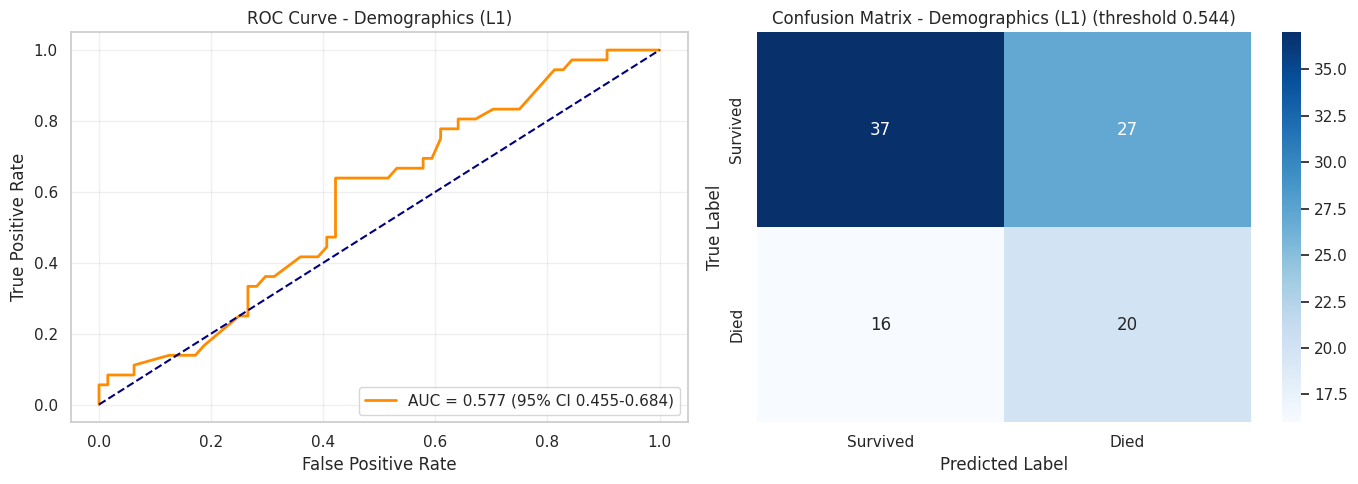


PROCESSING COHORT: L2
N=1,486 (489 died, 32.9%) | train 1,188 / val 149 / test 149 (49 deaths in test)
  LR: best C = 0.001 (val AUROC 0.7041)


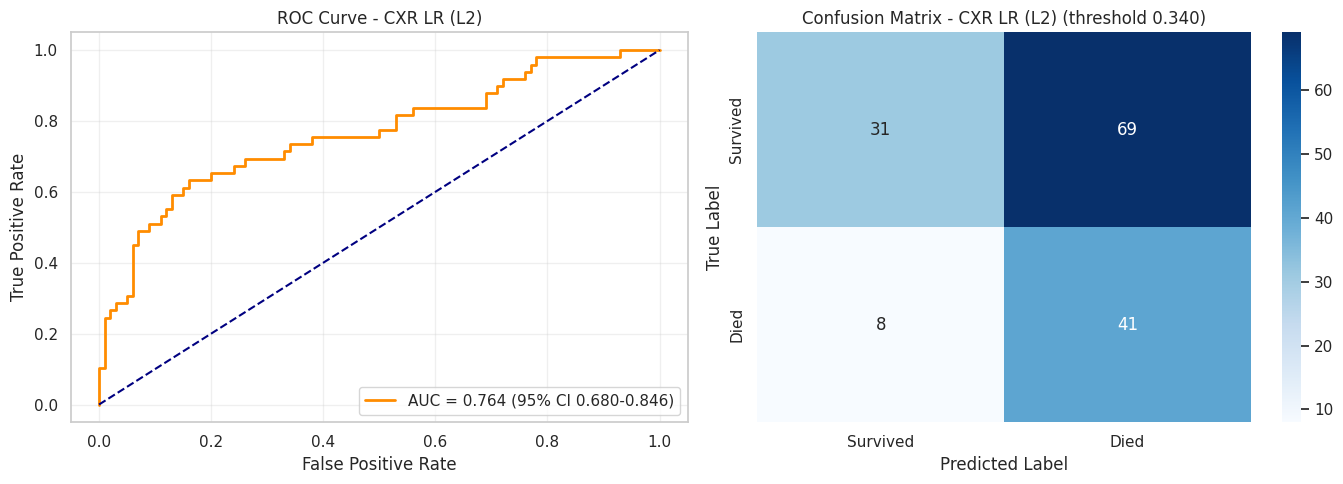

  NN: best hidden size = 128 (val loss 0.5359)


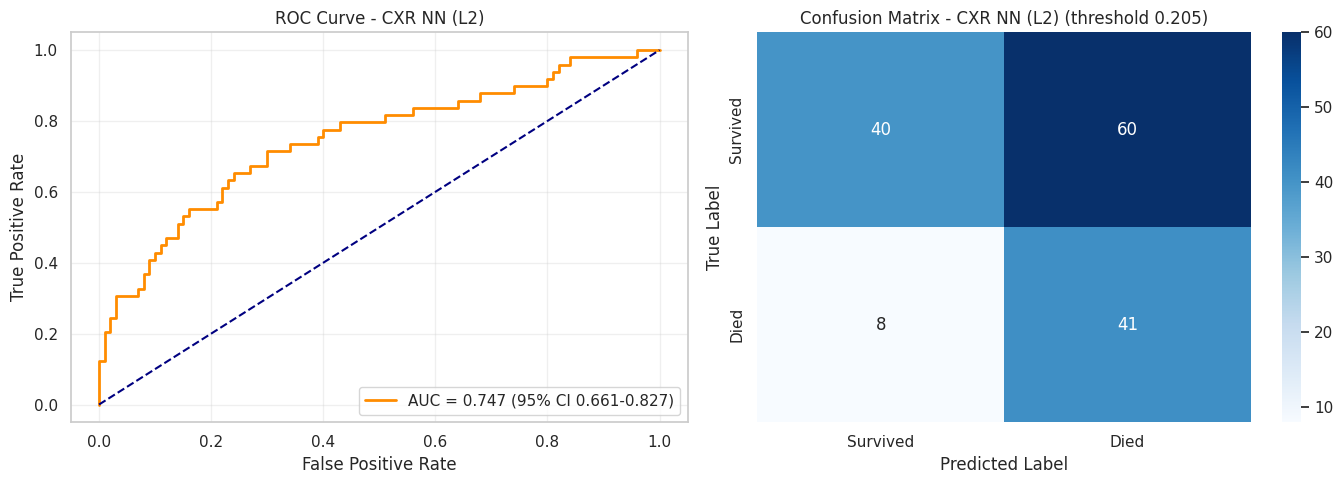

  LR: best C = 0.1 (val AUROC 0.7086)


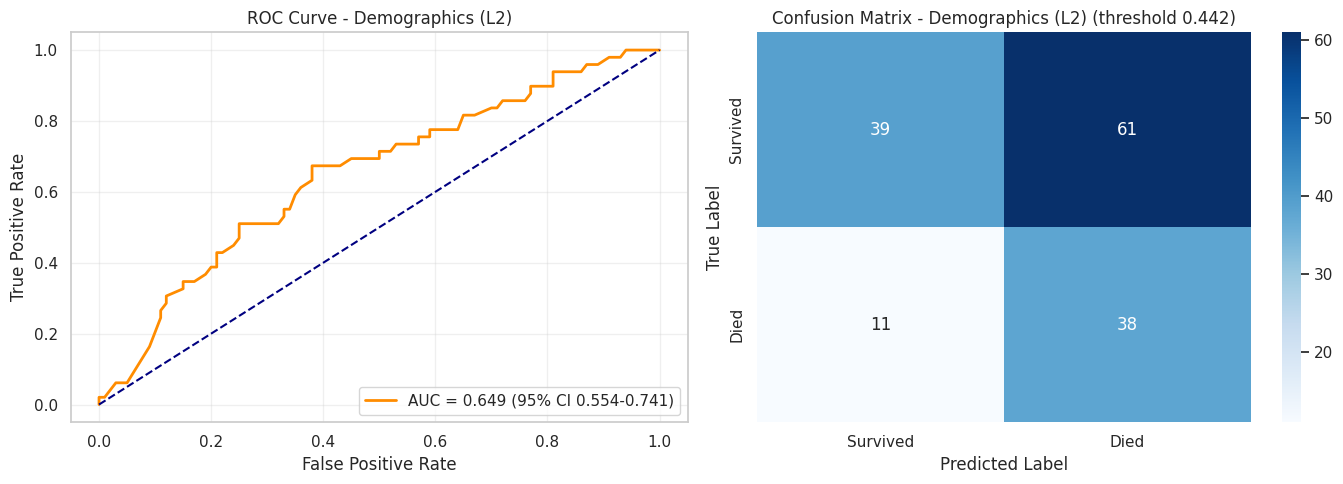


PROCESSING COHORT: L3
N=2,321 (584 died, 25.2%) | train 1,855 / val 233 / test 233 (59 deaths in test)
  LR: best C = 0.001 (val AUROC 0.7580)


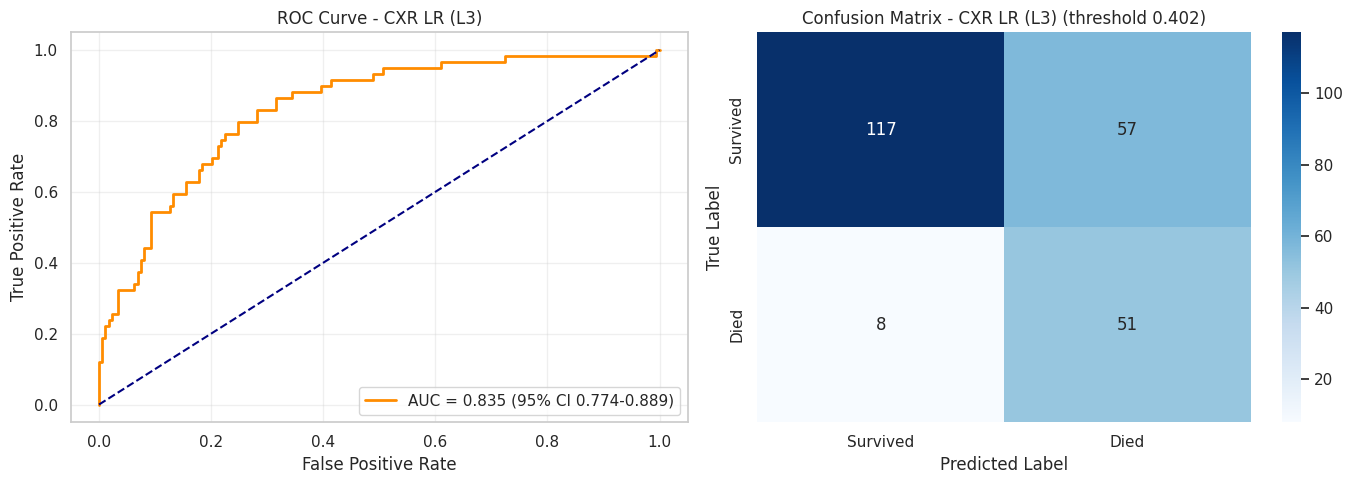

  NN: best hidden size = 128 (val loss 0.5068)


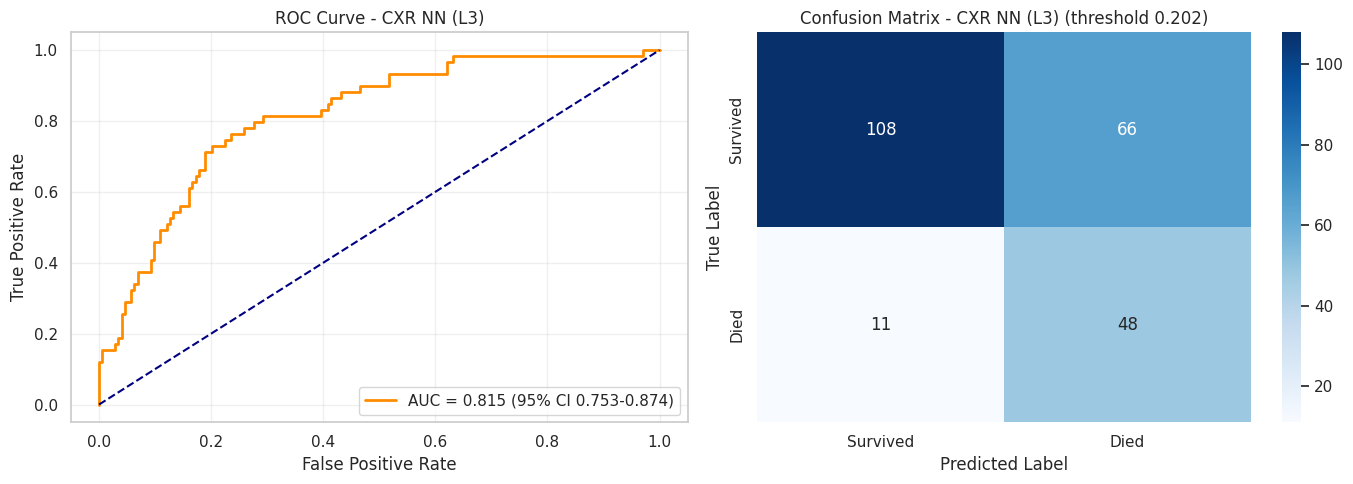

  LR: best C = 2.5 (val AUROC 0.6544)


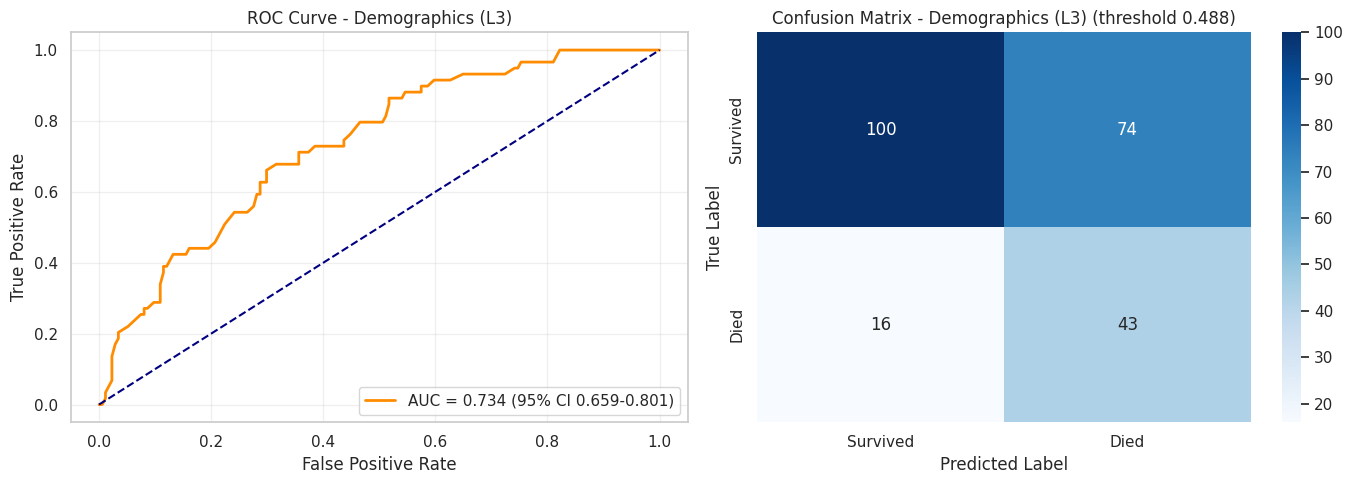


 PERFORMANCE COMPARISON (test set)


Model                       CXR: Logistic Regression CXR: Neural Network  \
Cohort Metric                                                              
L1     AUPRC                                  0.4637              0.4457   
       AUROC                                  0.5768              0.5495   
       AUROC 95% CI                      0.451-0.688         0.428-0.660   
       F1                                     0.4731              0.5421   
       NPV                                    0.6744              0.7586   
       PPV (Precision)                         0.386              0.4085   
       Sensitivity (Recall)                   0.6111              0.8056   
       Specificity                            0.4531              0.3438   
       Threshold                              0.2738              0.2076   
L2     AUPRC                                  0.6815              0.6525   
       AUROC                                  0.7645              0.7467   
       AUROC 95% CI                      0.680-0.846         0.661-0.827   
       F1                                     0.5157              0.5467   
       NPV                                    0.7949              0.8333   
       PPV (Precision)                        0.3727              0.4059   
       Sensitivity (Recall)                   0.8367              0.8367   
       Specificity                              0.31                 0.4   
       Threshold                              0.3401              0.2055   
L3     AUPRC                                  0.6548              0.6105   
       AUROC                                  0.8345               0.815   
       AUROC 95% CI                      0.774-0.889         0.753-0.874   
       F1                                     0.6108              0.5549   
       NPV                                     0.936              0.9076   
       PPV (Precision)                        0.4722              0.4211   
       Sensitivity (Recall)                   0.8644              0.8136   
       Specificity                            0.6724              0.6207   
       Threshold                              0.4016              0.2022   

Model                       Demographics (age+sex) Prior (chance)  
Cohort Metric                                                      
L1     AUPRC                                0.4468           0.36  
       AUROC                                0.5775            0.5  
       AUROC 95% CI                    0.455-0.684    0.500-0.500  
       F1                                   0.4819         0.5294  
       NPV                                  0.6981            0.0  
       PPV (Precision)                      0.4255           0.36  
       Sensitivity (Recall)                 0.5556            1.0  
       Specificity                          0.5781            0.0  
       Threshold                            0.5436         0.3551  
L2     AUPRC                                0.4623         0.3289  
       AUROC                                0.6492            0.5  
       AUROC 95% CI                    0.554-0.741    0.500-0.500  
       F1                                   0.5135         0.4949  
       NPV                                    0.78            0.0  
       PPV (Precision)                      0.3838         0.3289  
       Sensitivity (Recall)                 0.7755            1.0  
       Specificity                            0.39            0.0  
       Threshold                            0.4422         0.3291  
L3     AUPRC                                0.4594         0.2532  
       AUROC                                0.7338            0.5  
       AUROC 95% CI                    0.659-0.801    0.500-0.500  
       F1                                   0.4886         0.4041  
       NPV                                  0.8621            0.0  
       PPV (Precision)                      0.3675         0.2532  
       Sensitivity (Recall)

In [ ]:
cohorts = ['L1', 'L2', 'L3']
metric_names = ['AUROC', 'AUROC 95% CI', 'AUPRC', 'F1', 'PPV (Precision)', 'NPV',
                'Sensitivity (Recall)', 'Specificity', 'Threshold']
results_summary = []

for cohort in cohorts:
    print(f"\n{'=' * 50}\nPROCESSING COHORT: {cohort}\n{'=' * 50}")
    cohort_df = final_data_df[final_data_df['level_id'] == cohort]
    if cohort_df.empty:
        print(f"No data found for Cohort {cohort}.")
        continue

    (X_train, X_val, X_test, D_train, D_val, D_test,
     y_train, y_val, y_test) = split_cohort_data(cohort_df, embedding_cols, random_state=88)

    model_metrics = {}

    # 1. Image embeddings: logistic regression
    lr_model = train_logistic_classifier(X_train, y_train, X_val, y_val)
    t = youden_threshold(y_val, lr_model.predict_proba(X_val)[:, 1])
    model_metrics['CXR: Logistic Regression'] = evaluate_and_plot(
        y_test, lr_model.predict_proba(X_test)[:, 1], f"CXR LR ({cohort})", t)

    # 2. Image embeddings: neural network
    nn_model = train_nn_classifier(X_train, y_train, X_val, y_val)
    t = youden_threshold(y_val, nn_predict(nn_model, X_val))
    model_metrics['CXR: Neural Network'] = evaluate_and_plot(
        y_test, nn_predict(nn_model, X_test), f"CXR NN ({cohort})", t)

    # 3. Demographics only (age + sex): the baseline the image must beat
    demo_model = train_logistic_classifier(D_train, y_train, D_val, y_val)
    t = youden_threshold(y_val, demo_model.predict_proba(D_val)[:, 1])
    model_metrics['Demographics (age+sex)'] = evaluate_and_plot(
        y_test, demo_model.predict_proba(D_test)[:, 1], f"Demographics ({cohort})", t)

    # 4. Chance baseline: predicts the training mortality rate for everyone (AUROC = 0.5)
    dummy = DummyClassifier(strategy='prior').fit(X_train, y_train)
    model_metrics['Prior (chance)'] = evaluate_and_plot(
        y_test, dummy.predict_proba(X_test)[:, 1], f"Prior ({cohort})", threshold=y_train.mean(), plot=False)

    for model_name, m in model_metrics.items():
        for metric_name in metric_names:
            results_summary.append({'Cohort': cohort, 'Model': model_name,
                                    'Metric': metric_name, 'Value': m[metric_name]})

results_df = pd.DataFrame(results_summary)
pivot_df = results_df.pivot(index=['Cohort', 'Metric'], columns='Model', values='Value')
pivot_df = pivot_df.reindex(columns=['CXR: Logistic Regression', 'CXR: Neural Network',
                                     'Demographics (age+sex)', 'Prior (chance)'])

print("\n" + "=" * 50 + "\n PERFORMANCE COMPARISON (test set)\n" + "=" * 50)
display(pivot_df)
